In [1]:
from scipy.integrate import odeint
import numpy as np 
import matplotlib.pyplot as plt

# Driven RLC Circuit
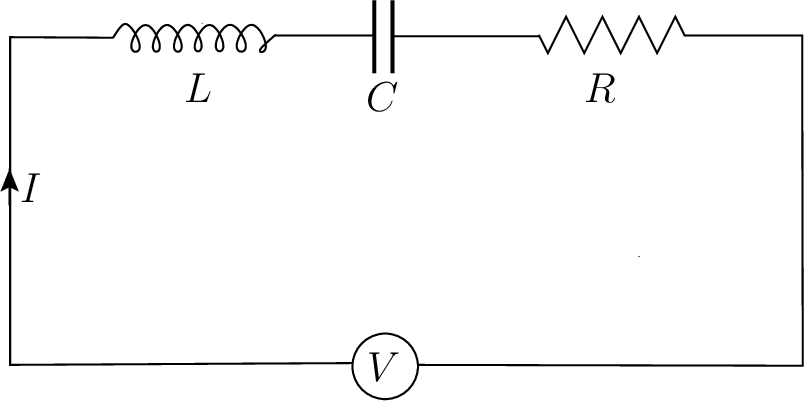

Applying Kirchhoff's Rule$$V(t)=V_{R}(t)+V_{L}(t)+V_{c}(t)$$

- $V_{R}(t)=IR$
- $V_{L}(t)=L \frac{dI}{dt}$
- $V_{c}(t)=\frac{Q}{C}$
- $I=\frac{dQ}{dt}$
- $P=IV$

$$V_{0}\sin(\omega t)=IR+L \frac{dI}{dt}+\frac{Q}{C}$$

$$\begin{eqnarray}
\frac{d^{2}Q}{dt^{2}}&=&-\frac{R}{L} \frac{dQ}{dt}-\frac{Q}{LC}+\frac{V_{0}}{L}\sin \omega t 
\\ \frac{dI}{dt}&=& -\frac{R}{L} I-\frac{Q}{LC}+\frac{V_{0}}{L}\sin \omega t 
\end{eqnarray}$$

#### Using Euler-Cromer Method for numerical 
difference equation
$$\begin{eqnarray}
\frac{I_{i+1}-I_{i}}{dt}&=&-\frac{R}{L}I_{i}-\frac{Q_{i}}{LC}+\frac{V_{0}}{L}\sin \omega t_{i}\\\therefore I_{i+1}&=&I_{i}-\left( \frac{R}{L}I_{i}+\frac{Q_{i}}{LC}-\frac{V_{0}}{L}\sin \omega t_{i} \right) dt\\ \\ \frac{Q_{i+1}-Q_{i}}{dt}&=& I_{i+1}\\ \therefore Q_{i+1}&=& Q_{i}+I_{i+1}dt
\end{eqnarray}$$

In [2]:
C=1e-6
L=1
R=100
FD=10

dt=0.0001
t = np.arange(0, 0.3+dt, dt)

In [3]:
def RLC (omega, C, L, R, FD, t, dt) :
    
    #Analytical Solution--------------------------------------------------------------------------------------------------------------- 
    def Qdot(I,t): 
        return [I[1], -(R/L)*I[1]-I[0]/(L*C)+(FD/L)*np.sin(omega*t)]
    A_Q , A_I = odeint(Qdot, [0,0], t).T

    A_V=FD*np.sin(omega*t) # calculating V=FDsin(omega t)
    A_P=A_I*A_V            # calculating P=IV

    #Numerical Solution (Euler-Cromer Method)------------------------------------------------------------------------------------------- 
    N_I = np.zeros(len(t))
    N_Q = np.zeros(len(t))

    #initial values
    N_I[0] = 0
    N_Q[0] = 0
  
    #using difference equation to calculate I,Q and iterating over t array
    for i in range(len(t)-1):
        N_I[i+1]=N_I[i]-((R/L)*N_I[i]+N_Q[i]/(L*C)-(FD/L)*np.sin(omega*t[i]))*dt
        N_Q[i+1]=N_Q[i]+N_I[i+1]*dt

    # calculating V,P
    N_V = N_I[:-1]*R + L*np.diff(N_I)/dt + N_Q[:-1]/C #calculating V = IR + L(dI/dt) + Q/C (using 2-point forward derivative to calculate dI/dt)
    N_P = N_I[:-1]* N_V                               #calculating P=IV
    
    return A_Q ,A_I, A_V, A_P,  N_I, N_Q, N_V, N_P

    

In [13]:
A_Q50 ,A_I50, A_V50, A_P50,  N_I50, N_Q50, N_V50, N_P50 = RLC (50, C, L, R, FD, t, dt)
A_Q60 ,A_I60, A_V60, A_P60,  N_I60, N_Q60, N_V60, N_P60 = RLC (60, C, L, R, FD, t, dt)
A_Q100,A_I100,A_V100, A_P100,  N_I100, N_Q100, N_V100, N_P100 = RLC (100, C, L, R, FD, t, dt)

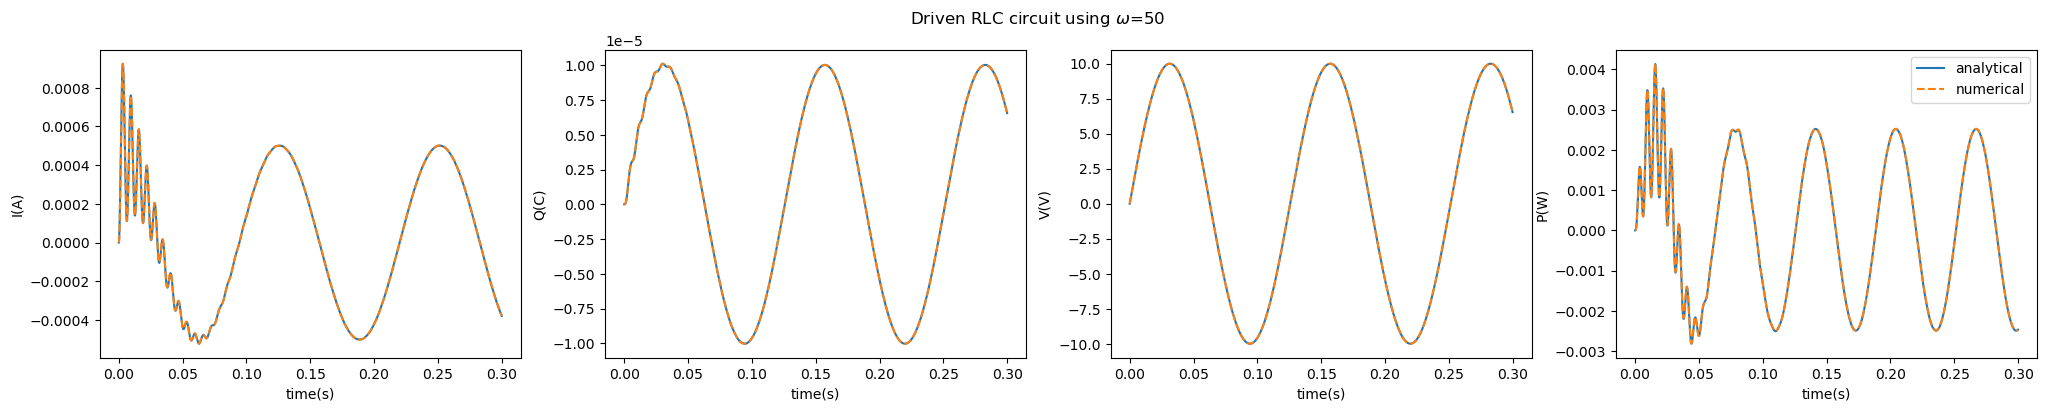

In [119]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 4))

fig.suptitle(r'Driven RLC circuit using $\omega$=50')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)

ax1.plot(t,      A_I50,          label = 'analytical')
ax1.plot(t,      N_I50,     '--',label = 'numerical' )
ax2.plot(t,      A_Q50,          label = 'analytical')
ax2.plot(t,      N_Q50,     '--',label = 'numerical' )
ax3.plot(t[:-1], A_V50[:-1],     label = 'analytical')
ax3.plot(t[:-1], N_V50,     '--',label = 'numerical')
ax4.plot(t[:-1], A_P50[:-1],     label = 'analytical')
ax4.plot(t[:-1], N_P50,     '--',label = 'numerical')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'I(A)', xlabel=r'time(s)')
ax2.set(ylabel=r'Q(C)', xlabel=r'time(s)')
ax3.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax4.set(ylabel=r'P(W)', xlabel=r'time(s)')
plt.legend()

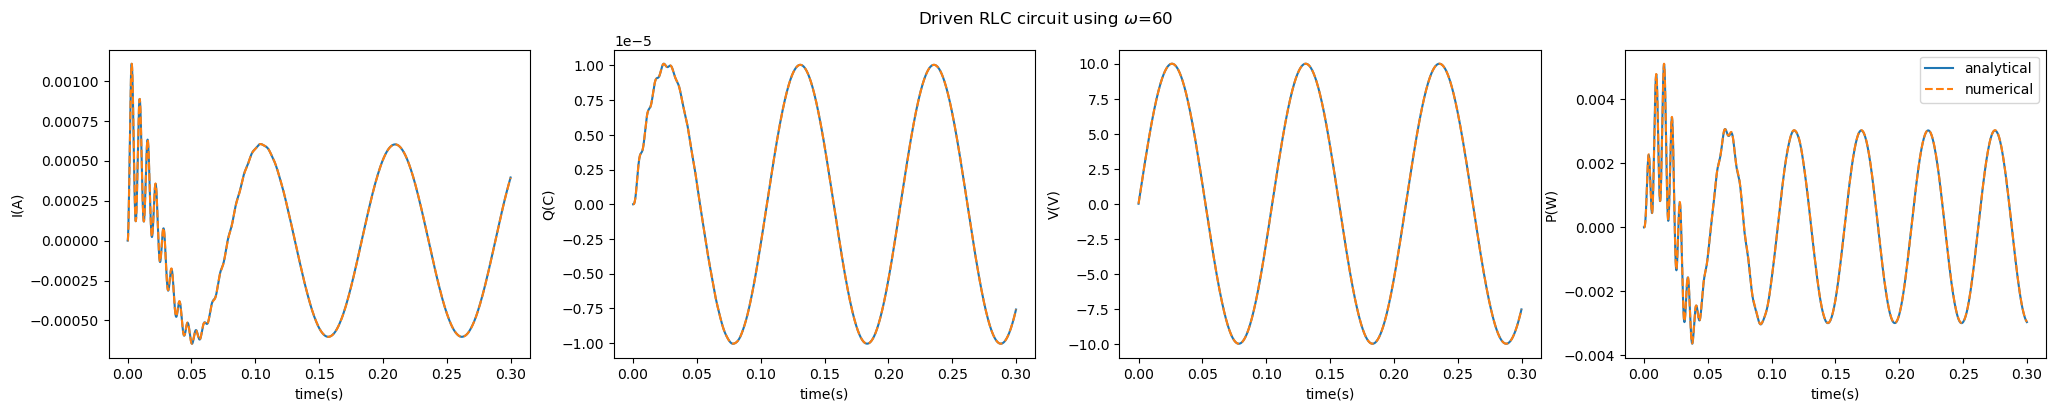

In [14]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 4))

fig.suptitle(r'Driven RLC circuit using $\omega$=60')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)

ax1.plot(t,      A_I60,          label = 'analytical')
ax1.plot(t,      N_I60,     '--',label = 'numerical' )
ax2.plot(t,      A_Q60,          label = 'analytical')
ax2.plot(t,      N_Q60,     '--',label = 'numerical' )
ax3.plot(t[:-1], A_V60[:-1],     label = 'analytical')
ax3.plot(t[:-1], N_V60,     '--',label = 'numerical')
ax4.plot(t[:-1], A_P60[:-1],     label = 'analytical')
ax4.plot(t[:-1], N_P60,     '--',label = 'numerical')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'I(A)', xlabel=r'time(s)')
ax2.set(ylabel=r'Q(C)', xlabel=r'time(s)')
ax3.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax4.set(ylabel=r'P(W)', xlabel=r'time(s)')
plt.legend()

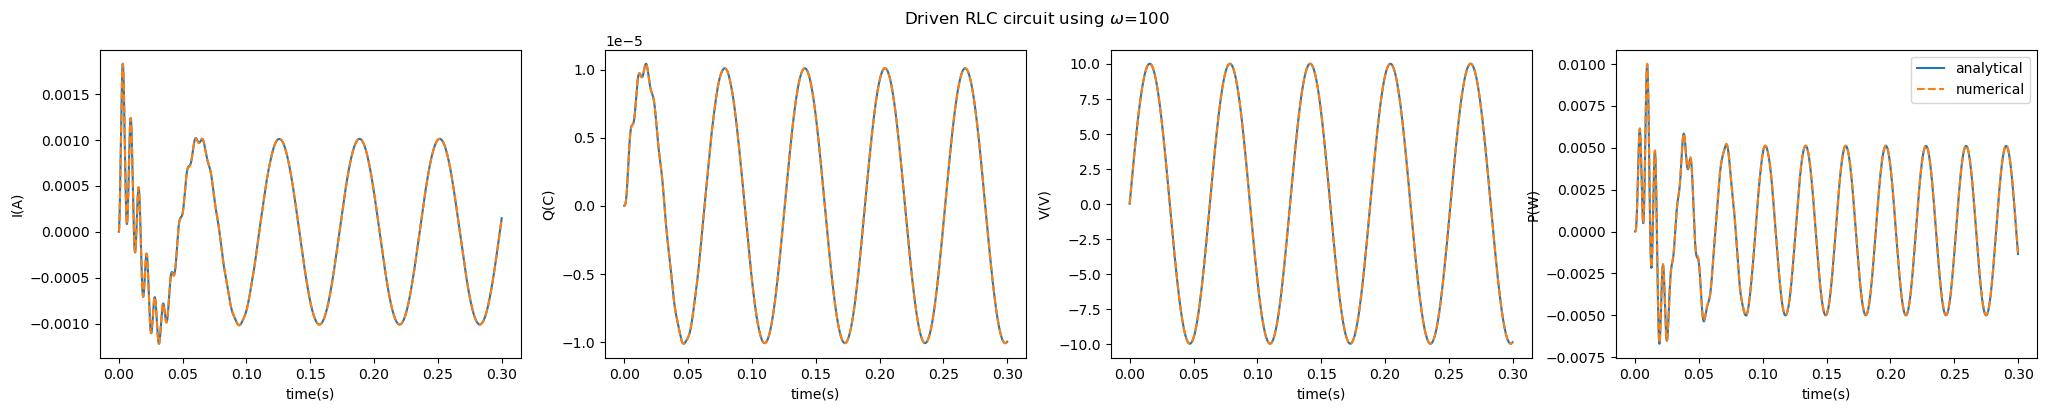

In [15]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 4))

fig.suptitle(r'Driven RLC circuit using $\omega$=100')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)

ax1.plot(t,      A_I100,          label = 'analytical')
ax1.plot(t,      N_I100,     '--',label = 'numerical' )
ax2.plot(t,      A_Q100,          label = 'analytical')
ax2.plot(t,      N_Q100,     '--',label = 'numerical' )
ax3.plot(t[:-1], A_V100[:-1],     label = 'analytical')
ax3.plot(t[:-1], N_V100,     '--',label = 'numerical')
ax4.plot(t[:-1], A_P100[:-1],     label = 'analytical')
ax4.plot(t[:-1], N_P100,     '--',label = 'numerical')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'I(A)', xlabel=r'time(s)')
ax2.set(ylabel=r'Q(C)', xlabel=r'time(s)')
ax3.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax4.set(ylabel=r'P(W)', xlabel=r'time(s)')
plt.legend()

### Changing Omega 
(using analytical data) 

Text(0, 0.5, 'V (V)')

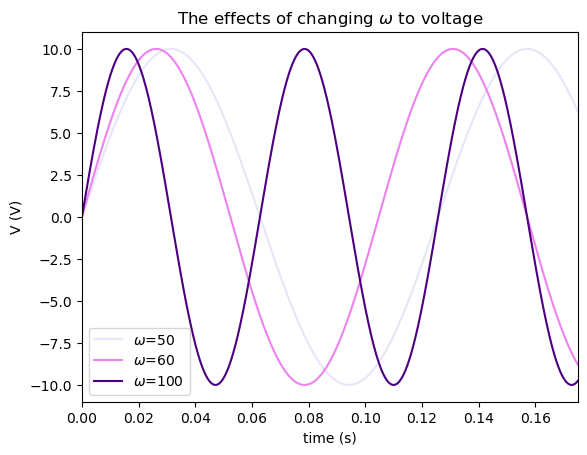

In [170]:
plt.plot(t, A_V50, label = r'$\omega$=50', color= 'lavender')
plt.plot(t, A_V60, label = r'$\omega$=60', color= 'violet' )
plt.plot(t, A_V100, label = r'$\omega$=100', color= 'indigo' )
plt.legend()
plt. xlim(0, 0.175)
plt.title(r'The effects of changing $\omega$ to voltage')
plt.xlabel('time (s)')  
plt.ylabel('V (V)')

Text(0, 0.5, 'V (V)')

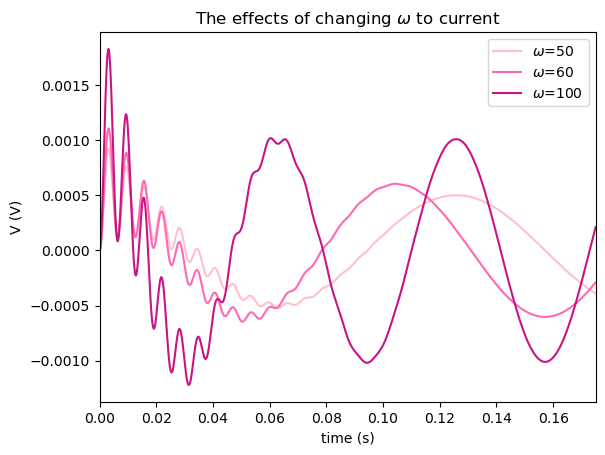

In [173]:
plt.plot(t, A_I50, label = r'$\omega$=50', color= 'pink')
plt.plot(t, A_I60, label = r'$\omega$=60', color= 'hotpink' )
plt.plot(t, A_I100, label =r'$\omega$=100', color= 'mediumvioletred' )
plt.legend()
plt. xlim(0, 0.175)
plt.title(r'The effects of changing $\omega$ to current')
plt.xlabel('time (s)')  
plt.ylabel('V (V)')

## $V_R, V_C, V_L$ 
using $\omega=100$
- $V_{R}(t)=IR$
- $V_{L}(t)=L \frac{dI}{dt}$
- $V_{c}(t)=\frac{Q}{C}$

In [154]:
def VandP_components (V, I, Q, R, L, C, dt) : 
    VT = V
    VR = I*R
    VL = L*np.diff(I)/dt
    VC = Q/C

    PT= I*VT
    PR = I*VR
    PL = I[:-1]*VL
    PC = I*VC
    
    return VT, VR, VL, VC, PT, PR, PL, PC

VT50, VR50, VL50, VC50, PT50, PR50, PL50, PC50 = VandP_components (A_V50, A_I50, A_Q50, R, L, C, dt)
VT60, VR60, VL60, VC60, PT60, PR60, PL60, PC60 = VandP_components (A_V60, A_I60, A_Q50, R, L, C, dt)
VT100, VR100, VL100, VC100, PT100, PR100, PL100, PC100 = VandP_components (A_V100, A_I100, A_Q50, R, L, C, dt)


(0.0, 0.15)

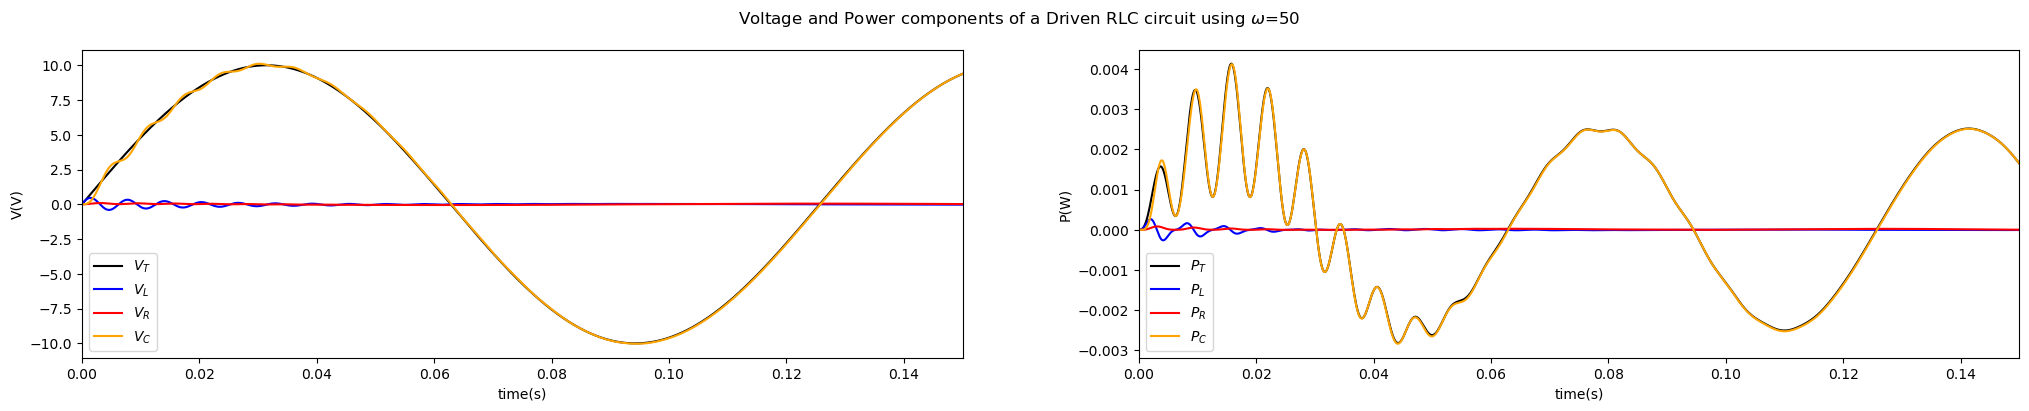

In [152]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega$=50')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)

ax1.plot(t,      VT50,     color = 'black' ,label = r'$V_T$',)
ax1.plot(t[:-1], VL50,     color = 'blue'  ,label = r'$V_L $') 
ax1.plot(t,      VR50,     color = 'red'   ,label = r'$V_R $') 
ax1.plot(t,      VC50,     color = 'orange',label = r'$V_C $') 
,
ax2.plot(t,      PT50,    color = 'black', label = r'$P_T$')
ax2.plot(t[:-1], PL50,    color = 'blue',  label = r'$P_L $')
ax2.plot(t,      PR50,    color = 'red',   label = r'$P_R $')
ax2.plot(t,      PC50,    color = 'orange',label = r'$P_C $')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.15)
ax2.set_xlim(0,0.15)

(0.0, 0.15)

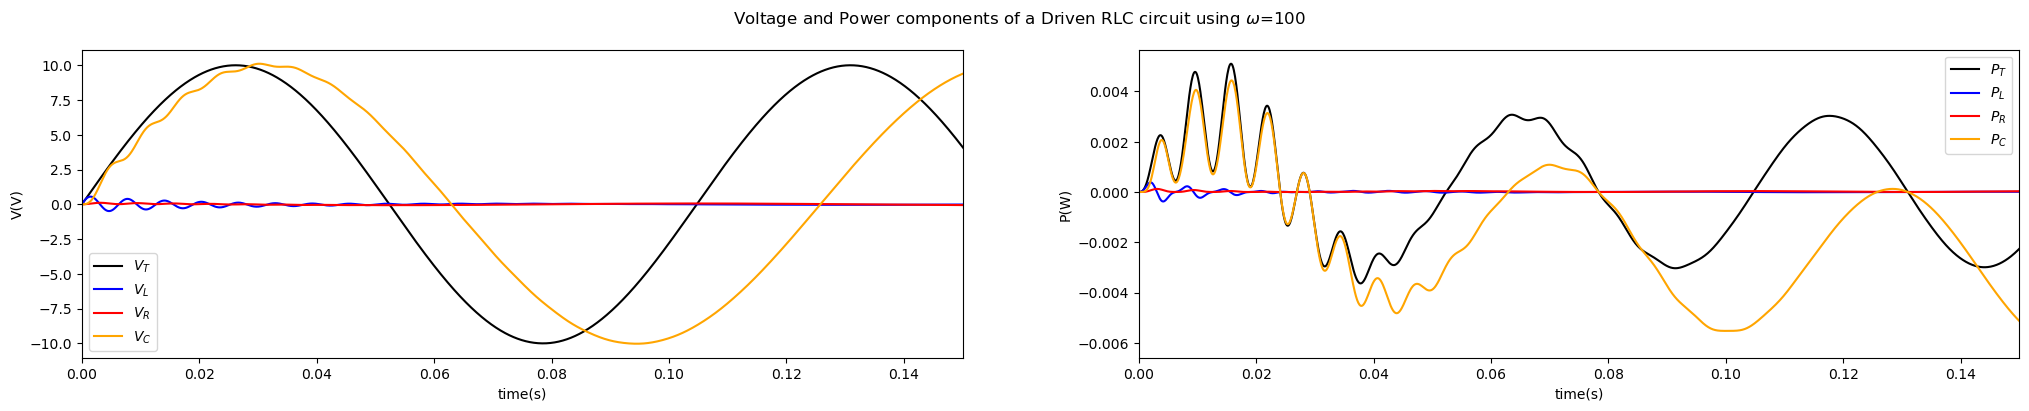

In [156]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega$=100')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)6

ax1.plot(t,      VT60,     color = 'black' ,label = r'$V_T$',)
ax1.plot(t[:-1], VL60,     color = 'blue'  ,label = r'$V_L $') 
ax1.plot(t,      VR60,     color = 'red'   ,label = r'$V_R $') 
ax1.plot(t,      VC60,     color = 'orange',label = r'$V_C $') 
,
ax2.plot(t,      PT60,    color = 'black', label = r'$P_T$')
ax2.plot(t[:-1], PL60,    color = 'blue',  label = r'$P_L $')
ax2.plot(t,      PR60,    color = 'red',   label = r'$P_R $')
ax2.plot(t,      PC60,    color = 'orange',label = r'$P_C $')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.15)
ax2.set_xlim(0,0.15)

(0.0, 0.15)

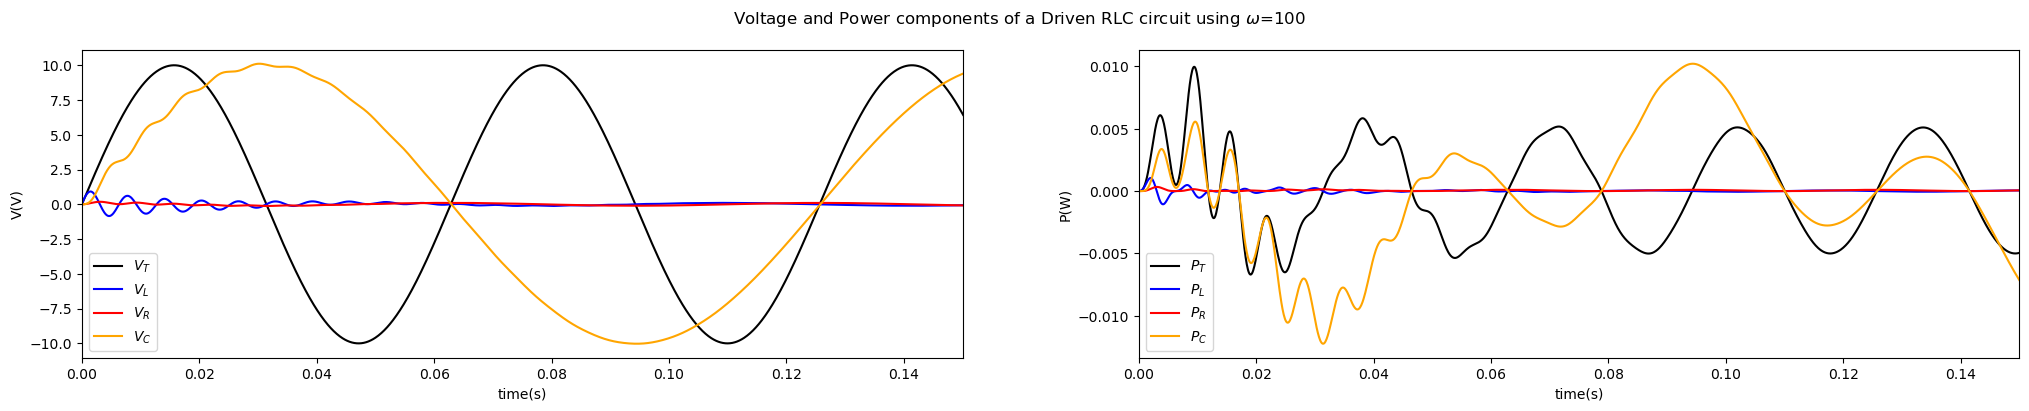

In [155]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 4))

fig.suptitle(r'Voltage and Power components of a Driven RLC circuit using $\omega$=100')
#ax1.set_xlim(0,100)
#ax2.set_xlim(0,100)6

ax1.plot(t,      VT100,     color = 'black' ,label = r'$V_T$',)
ax1.plot(t[:-1], VL100,     color = 'blue'  ,label = r'$V_L $') 
ax1.plot(t,      VR100,     color = 'red'   ,label = r'$V_R $') 
ax1.plot(t,      VC100,     color = 'orange',label = r'$V_C $') 

ax2.plot(t,      PT100,    color = 'black', label = r'$P_T$')
ax2.plot(t[:-1], PL100,    color = 'blue',  label = r'$P_L $')
ax2.plot(t,      PR100,    color = 'red',   label = r'$P_R $')
ax2.plot(t,      PC100,    color = 'orange',label = r'$P_C $')

#ax1.set_title(r"$F_D$ = 1.35")
#ax2.set_title(r"$F_D$ = 1.44")

ax1.set(ylabel=r'V(V)', xlabel=r'time(s)')
ax1.legend()
ax2.set(ylabel=r'P(W)', xlabel=r'time(s)')
ax2.legend()
ax1.set_xlim(0,0.15)
ax2.set_xlim(0,0.15)

## Impedance, Z against frequency
to find resonance frequency, $f_r$
$$\begin{eqnarray}
X_{L}&=& X_{C}\\ 2\pi fL&=& \frac{1}{2\pi fC}\\f&=&\sqrt{\frac{1}{4\pi^{2}LC}}=\frac{1}{2\pi \sqrt{LC}} = \frac{1}{2\pi \sqrt{1\times 1\mu}} = 159.155 Hz
\end{eqnarray}$$

In [61]:
f = np.arange(1,300,0.01)


XC = 1/(2*np.pi*f*C) 
XL = 2*np.pi*f*L

Z=np.sqrt(R**2+(XL-XC)**2)

In [161]:
fr = round(float(f[np.where(Z == np.min(Z))[0]]),4) ## to find the minimum point of Z (which is the resonant frequency)
minZ = int(np.min(Z))
print('The Resonant Frequency is',fr, 'Hz and happens when Z =', minZ )


The Resonant Frequency is 159.15 Hz and happens when Z = 100


C:\Users\Aisya Jasmin\AppData\Local\Temp\ipykernel_34112\1592461978.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fr = round(float(f[np.where(Z == np.min(Z))[0]]),4) ## to find the minimum point of Z (which is the resonant frequency)


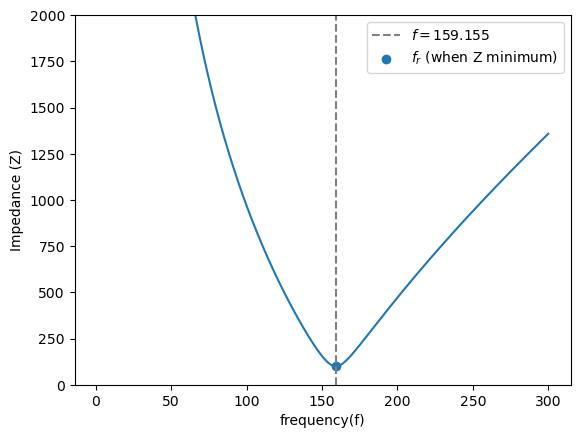

In [164]:
plt.plot(f,Z) 
plt.axvline(x=159.155, color='gray', linestyle='--', label=r'$f=159.155$')
plt.scatter(fr, minZ, label = r'$f_r$ (when Z minimum)')

plt.xlabel('frequency(f)') 
plt.ylabel("Impedance (Z)") 
plt.ylim(0,2000)
plt.legend()